# Linear Regression

> 📘 **Instructor Curriculum** — M07 Machine Learning, scikit-learn module.

Rough notes. One idea carries the whole file:

```text
y = coefficient * x + intercept
```

School wrote it as `y = mx + c`. Same line, longer names.

| Maths | sklearn | This notebook |
|---|---|---|
| slope `m` | `regressor.coef_` | `86.43` |
| intercept `c` | `regressor.intercept_` | `0.04` |

`fit()` finds those two numbers. `predict()` puts an `x` into that line.

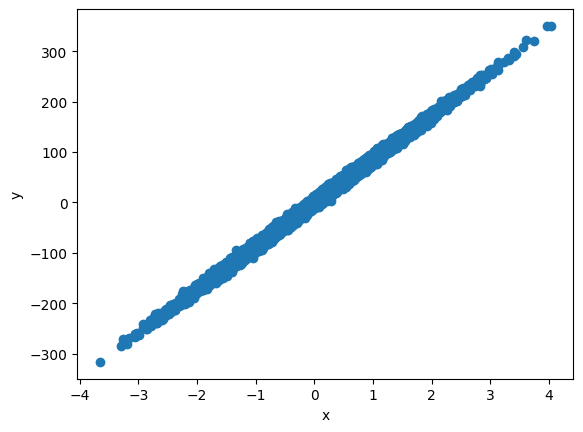

In [1]:
from sklearn.datasets import make_regression
x,y = make_regression(n_features=1, noise=5, n_samples=10000,random_state=1)
import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## 1. Look at the data first

`make_regression` builds fake data that already *is* a straight line.
`noise=5` scatters the dots a bit so it does not look too perfect.

`n_features=1` means one input column. So `x` has shape `(10000, 1)` — one column,
ten thousand rows.

The plot shows a band of dots going **up to the right**. That is what a positive
coefficient looks like. Our job is to find the one line that sits in the middle of
the band.

## 2. Split before fitting

8000 rows to learn from. 2000 rows kept hidden for the exam.
The model never sees `X_test` while it is learning.

In [2]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=0)


## 3. `fit()` — find the best line

`LinearRegression()` on its own knows nothing. It is an empty box.

`fit(X_train, y_train)` tries lines and keeps the one where the total error is
smallest. Error = the vertical gap between a real dot and the line.

After `fit`, the box holds exactly **two numbers**. 8000 rows went in, 2 floats came
out. The rows are not kept.

```mermaid
flowchart LR
    A["X_train, y_train<br/>8000 rows"] --> B["fit()"]
    B --> C["coef_ = 86.43<br/>intercept_ = 0.04"]
    E["a new x"] --> D["predict()"]
    C --> D
    D --> F["y = 86.43 * x + 0.04"]
    style C fill:#2f6fed,color:#fff
    style F fill:#2f9e6f,color:#fff
```

Anything `fit` learns is stored with a **trailing underscore** — `coef_`, `intercept_`.
No underscore means you typed it in. Underscore means the data taught it.

In [3]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[86.43]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.04227
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[89.35]


## 4. The test input

2000 rows, one column each.

Notice the double brackets — `[[ 1.24445906 ]]`. It is a 2-D array. sklearn always
wants `X` as a table, even when the table has only one column.

In [4]:
X_test

array([[ 1.24445906],
       [ 0.98495167],
       [-1.59370261],
       ...,
       [ 0.24745387],
       [ 0.05529735],
       [ 0.07425068]], shape=(2000, 1))

## 5. `predict()` — run the formula

No learning happens here. For every row it only does:

```text
86.43 * x + 0.04
```

Check the first row by hand: `86.43 * 1.24445906 + 0.04 = 107.6`.
That is exactly the first predicted value.

In [5]:
regressor.predict(X_test)

array([ 107.6063556 ,   85.17598825, -137.70846548, ...,   21.43080311,
          4.82186867,    6.46008839], shape=(2000,))

## 6. `score()` — how good is the line

For a regression model, `score` returns **R²**.

- `1.0` → the line passes through every point.
- `0.0` → the line is no better than always guessing the average of `y`.

We got `0.9966`. The line explains about 99.7% of the movement in `y`. It is this
high only because the data was generated as a straight line. Real data is messier.

In [6]:
regressor.score(X_test,y_test)

0.9966263246017432

## 7. `coef_` — the coefficient (the slope)

**Coefficient = how much `y` moves when `x` goes up by 1.**

Ours is `86.43`. One step right on the x-axis, and the line climbs 86.43 upwards.

```text
        y
        │              ●
        │             /│
        │            / │   rise = 86.43   ← coef_
        │           /  │
        │          ●───┘
        │          run = 1
        └──────────────────── x
```

It comes back as an **array**, not a single number — `array([86.43440685])`.
One entry per input column. We have 1 column, so 1 coefficient. With 5 columns you
would get 5 of them.

The sign tells the direction:

| Sign | Meaning |
|---|---|
| `+` | x goes up, y goes up |
| `−` | x goes up, y goes down |
| near `0` | this column barely matters |

In [7]:
regressor.coef_

array([86.43440685])

## 8. `intercept_` — the starting point

**Intercept = the value of `y` when `x` is 0.** It is where the line crosses the
vertical axis.

Ours is `0.042`, almost zero, because `make_regression` centres its data on the
origin. So our line passes through roughly `(0, 0)`.

It is a plain float, not an array. One line has one starting height.

Short version: **the coefficient tilts the line, the intercept slides it up and
down.** A straight line has only those two knobs.

In [8]:
regressor.intercept_

np.float64(0.042274723015908955)

## 9. Proof — rebuild `predict()` by hand

If `predict()` really is just `m * x + c`, then writing the formula ourselves must
give the same numbers.

In [9]:
import numpy as np

m = regressor.coef_[0]        # the slope        (coefficient)
c = regressor.intercept_      # the height at x=0 (intercept)

by_hand  = m * X_test + c
by_sklearn = regressor.predict(X_test)

print("first 3 by hand   :", by_hand.ravel()[:3])
print("first 3 by sklearn:", by_sklearn[:3])
print("same? ->", np.allclose(by_hand.ravel(), by_sklearn))

first 3 by hand   : [ 107.6063556    85.17598825 -137.70846548]
first 3 by sklearn: [ 107.6063556    85.17598825 -137.70846548]
same? -> True


`True`. There is nothing hidden inside `predict()`. It is one multiply and one add.

## 10. The same two numbers, drawn on the real data

Black dot = the intercept. Green triangle = the coefficient.

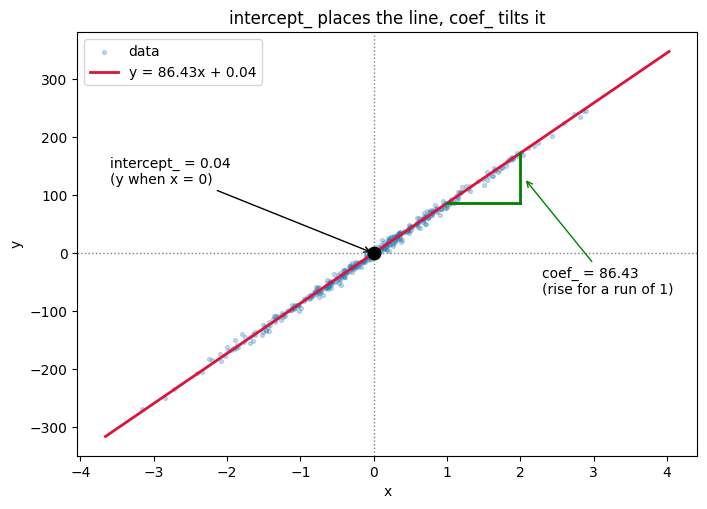

In [10]:
line_x = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
line_y = regressor.predict(line_x)

plt.figure(figsize=(8, 5.5))
plt.scatter(x[:400], y[:400], s=8, alpha=0.25, label="data")
plt.plot(line_x, line_y, color="crimson", lw=2, label=f"y = {m:.2f}x + {c:.2f}")

# --- intercept: where the line crosses x = 0 ---
plt.axvline(0, color="grey", ls=":", lw=1)
plt.axhline(0, color="grey", ls=":", lw=1)
plt.scatter([0], [c], color="black", zorder=5, s=80)
plt.annotate(f"intercept_ = {c:.2f}\n(y when x = 0)",
             xy=(0, c), xytext=(-3.6, 120),
             arrowprops=dict(arrowstyle="->", color="black"))

# --- coefficient: the rise over a run of 1 ---
plt.plot([1, 2], [m*1 + c, m*1 + c], color="green", lw=2)   # run  = 1
plt.plot([2, 2], [m*1 + c, m*2 + c], color="green", lw=2)   # rise = coef_
plt.annotate(f"coef_ = {m:.2f}\n(rise for a run of 1)",
             xy=(2.05, m*1.5 + c), xytext=(2.3, -70),
             arrowprops=dict(arrowstyle="->", color="green"))

plt.xlabel("x"); plt.ylabel("y"); plt.legend(loc="upper left")
plt.title("intercept_ places the line, coef_ tilts it")
plt.show()

## 11. What each knob actually does

Turn one knob at a time and watch what changes.

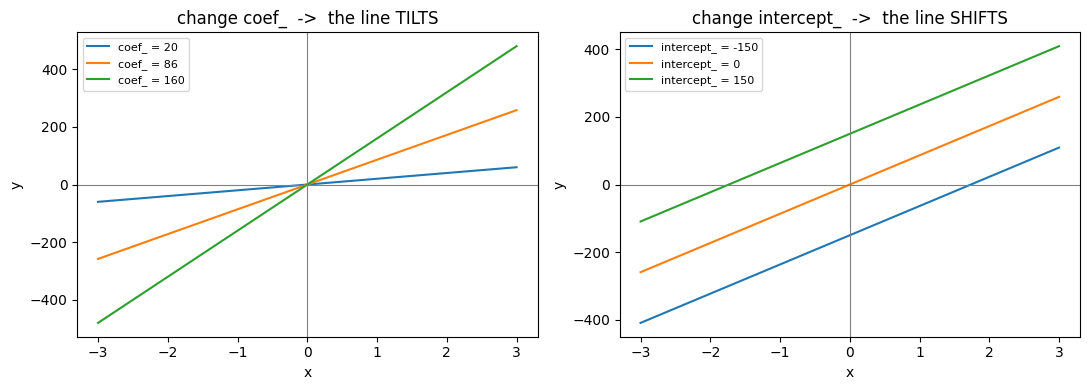

In [11]:
xs = np.linspace(-3, 3, 50)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

for slope in [20, 86, 160]:                      # intercept fixed
    ax[0].plot(xs, slope * xs + c, label=f"coef_ = {slope}")
ax[0].set_title("change coef_  ->  the line TILTS")

for shift in [-150, 0, 150]:                     # slope fixed
    ax[1].plot(xs, m * xs + shift, label=f"intercept_ = {shift}")
ax[1].set_title("change intercept_  ->  the line SHIFTS")

for a in ax:
    a.axhline(0, color="grey", lw=0.8)
    a.axvline(0, color="grey", lw=0.8)
    a.set_xlabel("x"); a.set_ylabel("y"); a.legend(fontsize=8)

plt.tight_layout(); plt.show()

Left: all three lines cross the axis at the same place, but lean differently.
That is the **coefficient**.

Right: all three lines lean the same, but sit at different heights.
That is the **intercept**.

`fit()` picked the one pair of knob settings that puts the line closest to our dots.

## 12. Predict on all 10000 rows

The same formula, applied to the whole dataset this time, so we can draw predictions
next to the real values.

In [12]:
y_pred = regressor.predict(x)
y_pred

array([ 130.08472986,  -44.53477921, -167.86426893, ..., -142.37365931,
         13.8749839 ,  -72.20838078], shape=(10000,))

## 13. Actual vs predicted

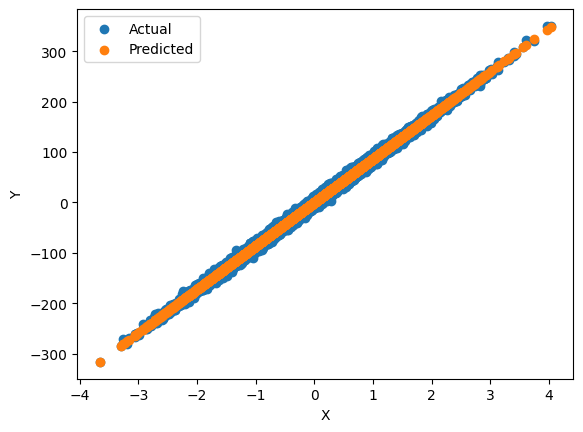

In [13]:
plt.scatter(x,y,label="Actual")
plt.scatter(x,y_pred,label="Predicted")
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

Blue = the real, noisy dots. Orange = the predictions.

The orange points form a perfectly straight line. They have to — every one of them
came out of `86.43 * x + 0.04`. A model's predictions can never be more crooked than
the model itself.

The blue cloud sitting evenly around the orange line is the sign of a good fit. If
the blue dots curved away from the orange line, a straight line would be the wrong
model for this data.

## Takeaway

If you remember only one thing: **`fit()` squeezes thousands of rows into two
numbers, and `predict()` is nothing more than those two numbers in
`y = coef_ * x + intercept_`.**

| | Question it answers | Type | Value here |
|---|---|---|---|
| `coef_` | how steep is the line? | array, one per input column | `[86.43]` |
| `intercept_` | where does the line start? | single float | `0.04` |

With many columns the formula just gets longer, one coefficient each, still one
intercept:

```text
y = c0*x0 + c1*x1 + c2*x2 + ... + intercept
```